# Project 02 — NHS Regional Health Outcomes
## Phase 1 | Era 1 | Difficulty: Medium | DDaT: HEO Level

| Field | Detail |
|---|---|
| **Portfolio** | insightful-algorithms |
| **Phase** | 1 — EDA & Statistical Analysis |
| **Era** | 1 — Classical Statistics |
| **Difficulty** | Medium |
| **DDaT Level** | HEO |
| **Civil Service Behaviour** | Communicating and Influencing |
| **Dataset** | OHID Fingertips Local Authority Health Profiles + ONS Life Expectancy |
| **Key Techniques** | Bivariate analysis, Pearson correlation, GroupBy aggregation, t-test |

### Objective
Analyse regional variation in health outcomes across English local authorities.
Identify the relationship between deprivation and life expectancy. Communicate
findings as a structured policy briefing for a non-technical public health audience —
demonstrating the Civil Service behaviour of **Communicating and Influencing** at
HEO level.

### Civil Service Behaviour — Communicating and Influencing
> *"Communicate purpose and direction with clarity, integrity and enthusiasm.
> Respect the needs, responses and opinions of others."*

This project frames all findings as a policy briefing for a Director of Public Health —
a non-technical stakeholder audience. Every analytical decision is documented with
a plain-English rationale. Visualisations are designed to be immediately interpretable
without statistical training.

## Table of Contents

1. [Environment Setup](#1-environment-setup)
2. [Data Loading and Profiling](#2-data-loading-and-profiling)
3. [Data Selection and Cleaning](#3-data-selection-and-cleaning)
4. [Univariate Analysis](#4-univariate-analysis)
5. [Bivariate Analysis — Deprivation vs Health Outcomes](#5-bivariate-analysis)
6. [GroupBy Analysis — Regional Patterns](#6-groupby-analysis)
7. [Statistical Testing — North vs South](#7-statistical-testing)
8. [Key Findings — Policy Briefing](#8-key-findings--policy-briefing)

## 1. Environment Setup

Verify working directory, Python interpreter, and library versions before
any analysis begins. This ensures full reproducibility — anyone running
this notebook will immediately know if their environment does not match.

**Key rule:** Working directory must be the project root (`project2\`),
not the `notebooks\` subfolder. All data paths are written relative to
the project root using `os.path.join()`.

In [2]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import scipy
from scipy import stats

# Confirm working directory — must be project root
print("Working directory:", os.getcwd())

# ── Python interpreter check ─────────────────────────────────────────────────
# Must show project2\ds_env path, not system Python313 or project1
print("Python interpreter:", sys.executable)


# Library versions
print(f"pandas:     {pd.__version__}")
print(f"numpy:      {np.__version__}")
print(f"matplotlib: {plt.matplotlib.__version__}")
print(f"seaborn:    {sns.__version__}")
print(f"scipy:      {scipy.__version__}")

Working directory: C:\Users\TEST\OneDrive\Documents\The United Kingdom\Jobs\Data Science\portfolio\project2
Python interpreter: C:\Users\TEST\OneDrive\Documents\The United Kingdom\Jobs\Data Science\portfolio\project2\ds_env\Scripts\python.exe
pandas:     3.0.1
numpy:      2.4.4
matplotlib: 3.10.8
seaborn:    0.13.2
scipy:      1.17.1


## 2. Data Loading and Profiling

We downloaded seven files from two sources:
- **OHID Fingertips** — Local Authority Health Profiles (all indicators, all areas)
- **ONS** — Life expectancy and healthy life expectancy by local area

Before selecting which files to use for analysis, we profile every file to
understand its structure, shape, columns and data quality. This is standard
practice in any professional data science workflow — never assume, always inspect.

### The `profile_dataframe()` Function

This reusable utility function was first built in Project 01 and is carried
forward here. It profiles any DataFrame in a consistent, repeatable way —
reporting shape, column names, data types, and missing values in one call.
Reusing it across projects is good software engineering practice: write once,
use everywhere.

In [3]:
def profile_dataframe(df, name="DataFrame"):
    """
    Profile a DataFrame: shape, dtypes, missing values, and basic stats.

    Reusable utility carried forward from Project 01. Provides a consistent,
    repeatable summary of any DataFrame before analysis begins.

    Parameters
    ----------
    df : pd.DataFrame
        The DataFrame to profile.
    name : str, optional
        Label to display in the output header. Default is 'DataFrame'.

    Returns
    -------
    None
        Prints profile summary to stdout.

    Examples
    --------
    >>> profile_dataframe(df, name="NHS Health Profiles")
    """
    print(f"\n{'='*60}")
    print(f"PROFILE: {name}")
    print(f"{'='*60}")
    print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
    print(f"\nColumn names:\n{df.columns.tolist()}")
    print(f"\nData types:\n{df.dtypes.to_string()}")

    # Missing values — only show columns that have at least one missing value
    missing = df.isnull().sum()
    missing_pct = (missing / len(df) * 100).round(2)
    missing_df = pd.DataFrame({
        'Missing Count': missing,
        'Missing %': missing_pct
    })
    missing_df = missing_df[missing_df['Missing Count'] > 0]

    if len(missing_df) == 0:
        print(f"\nMissing values: None")
    else:
        print(f"\nMissing values (columns with gaps only):\n{missing_df.to_string()}")

    print(f"\nFirst 3 rows:\n{df.head(3).to_string()}")

### 2.1 Load All Raw Files

We load all seven downloaded files and profile each one systematically.
Excel files may contain multiple sheets — we check sheet names before
loading to ensure we read the correct one.

In [5]:
raw = os.path.join('data', 'raw')  # Relative to project root

# File registry — key: friendly name, value: (filename, filetype)
# Using a dictionary makes it easy to add or remove files without
# changing the loading logic below
files = {
    'le_single_year':     ('lifeexpectancysingleyearperiods.xlsx', 'xlsx'),
    'le_local_areas':     ('lifeexpectancylocalareas.xlsx',        'xlsx'),
    'hle_uk':             ('healthylifeexpectancyuk.xlsx',         'xlsx'),
    'la_metadata':        ('LocalAuthorityHealthProfiles.metadata.csv', 'csv'),
    'indicators_1':       ('indicators-England.data.csv',          'csv'),
    'indicators_2':       ('indicators-England.data (1).csv',      'csv'),
    'all_indicators_meta':('Allindicators.metadata.csv',           'csv'),
}

dfs = {}  # Store all loaded DataFrames here

for key, (fname, ftype) in files.items():
    fpath = os.path.join(raw, fname)
    print(f"\nLoading: {fname}")
    try:
        if ftype == 'xlsx':
            xl = pd.ExcelFile(fpath)
            print(f"  Sheets found: {xl.sheet_names}")
            dfs[key] = pd.read_excel(fpath, sheet_name=0)
        else:
            dfs[key] = pd.read_csv(fpath, encoding='utf-8', low_memory=False)
        print(f"  Loaded successfully: {dfs[key].shape[0]:,} rows x {dfs[key].shape[1]} columns")
    except Exception as e:
        print(f"  ERROR: {e}")


Loading: lifeexpectancysingleyearperiods.xlsx
  Sheets found: ['Cover_sheet', 'Contents', 'Notes', '1', '2']
  Loaded successfully: 26 rows x 1 columns

Loading: lifeexpectancylocalareas.xlsx
  Sheets found: ['Cover_sheet', 'Contents', 'Notes', '1', '2']
  Loaded successfully: 23 rows x 1 columns

Loading: healthylifeexpectancyuk.xlsx
  Sheets found: ['Cover_sheet', 'Contents', 'Notes', '1', '2', '3']
  Loaded successfully: 23 rows x 1 columns

Loading: LocalAuthorityHealthProfiles.metadata.csv
  Loaded successfully: 36 rows x 32 columns

Loading: indicators-England.data.csv
  Loaded successfully: 12,921 rows x 27 columns

Loading: indicators-England.data (1).csv
  Loaded successfully: 12,376 rows x 27 columns

Loading: Allindicators.metadata.csv
  Loaded successfully: 32 rows x 32 columns


### 2.2 Profile Each Dataset

We profile every file before making any decisions about which to use.
This reveals structure, data types, missing values and the first few
rows of actual data — giving us everything we need to make an informed
selection decision.

In [6]:
for key, df in dfs.items():
    profile_dataframe(df, name=key)


PROFILE: le_single_year
Shape: 26 rows x 1 columns

Column names:
['Life expectancy for local areas of Great Britain: single year periods, 2011 to 2023']

Data types:
Life expectancy for local areas of Great Britain: single year periods, 2011 to 2023    str

Missing values: None

First 3 rows:
  Life expectancy for local areas of Great Britain: single year periods, 2011 to 2023
0                                                                         Information
1                                              Source: Office for National Statistics
2                                                           Released: 4 December 2024

PROFILE: le_local_areas
Shape: 23 rows x 1 columns

Column names:
['Life expectancy for local areas of Great Britain: between 2001 to 2003 and 2021 to 2023']

Data types:
Life expectancy for local areas of Great Britain: between 2001 to 2003 and 2021 to 2023    str

Missing values: None

First 3 rows:
  Life expectancy for local areas of Great Britain: betw

---
## 3. Data Selection and Cleaning

### 3.1 Investigate the ONS Excel Files

The three ONS Excel files loaded with only 1 column of metadata text —
this means `pd.read_excel()` defaulted to sheet 0, which is a cover sheet.
We need to check all sheets in each file to find the actual data.

In [7]:
# The three ONS Excel files each have multiple sheets
# Sheet 0 is a cover/information sheet — not the data
# We need to inspect all sheet names and preview each one
# to find which sheet contains the actual local authority data

excel_files = {
    'le_single_year': os.path.join(raw, 'lifeexpectancysingleyearperiods.xlsx'),
    'le_local_areas': os.path.join(raw, 'lifeexpectancylocalareas.xlsx'),
    'hle_uk':         os.path.join(raw, 'healthylifeexpectancyuk.xlsx'),
}

for name, fpath in excel_files.items():
    print(f"\n{'='*60}")
    print(f"FILE: {name}")
    print(f"{'='*60}")
    xl = pd.ExcelFile(fpath)
    print(f"All sheets: {xl.sheet_names}")
    
    # Preview first 3 rows of every sheet to find the data sheet
    for sheet in xl.sheet_names:
        df_sheet = pd.read_excel(fpath, sheet_name=sheet, nrows=3)
        print(f"\n  Sheet: '{sheet}' — shape preview: {df_sheet.shape}")
        print(f"  Columns: {df_sheet.columns.tolist()}")


FILE: le_single_year
All sheets: ['Cover_sheet', 'Contents', 'Notes', '1', '2']

  Sheet: 'Cover_sheet' — shape preview: (3, 1)
  Columns: ['Life expectancy for local areas of Great Britain: single year periods, 2011 to 2023']

  Sheet: 'Contents' — shape preview: (3, 2)
  Columns: ['Table of contents', 'Unnamed: 1']

  Sheet: 'Notes' — shape preview: (3, 2)
  Columns: ['Notes', 'Unnamed: 1']

  Sheet: '1' — shape preview: (3, 1)
  Columns: ['Sheet 1: Life expectancy for local areas of Great Britain by age and sex: single year periods, 2011 to 2023']

  Sheet: '2' — shape preview: (3, 1)
  Columns: ['Sheet 2: Life expectancy for local areas of Great Britain by age and sex: single year periods, 2011 to 2023, pivot table']

FILE: le_local_areas
All sheets: ['Cover_sheet', 'Contents', 'Notes', '1', '2']

  Sheet: 'Cover_sheet' — shape preview: (3, 1)
  Columns: ['Life expectancy for local areas of Great Britain: between 2001 to 2003 and 2021 to 2023']

  Sheet: 'Contents' — shape preview

### 3.2 Investigate the Difference Between indicators_1 and indicators_2

`indicators_1` has 12,921 rows and `indicators_2` has 12,376 rows —
a difference of 545 rows. They have identical column structures.
We need to establish whether they cover different area types,
different indicators, or different time periods — before deciding
whether to use one or both.

In [8]:
df1 = dfs['indicators_1']
df2 = dfs['indicators_2']

# Compare area types covered in each file
# Area Type column tells us the geographic level of each row
print("=== AREA TYPES IN indicators_1 ===")
print(df1['Area Type'].value_counts().to_string())

print("\n=== AREA TYPES IN indicators_2 ===")
print(df2['Area Type'].value_counts().to_string())

# Compare indicators covered in each file
print("\n=== INDICATORS IN indicators_1 ===")
print(sorted(df1['Indicator Name'].unique().tolist()))

print("\n=== INDICATORS IN indicators_2 ===")
print(sorted(df2['Indicator Name'].unique().tolist()))

# Check if one is a subset of the other
in_1_not_2 = set(df1['Indicator Name'].unique()) - set(df2['Indicator Name'].unique())
in_2_not_1 = set(df2['Indicator Name'].unique()) - set(df1['Indicator Name'].unique())

print(f"\nIndicators in file 1 but NOT file 2: {in_1_not_2}")
print(f"Indicators in file 2 but NOT file 1: {in_2_not_1}")

=== AREA TYPES IN indicators_1 ===
Area Type
England    12921

=== AREA TYPES IN indicators_2 ===
Area Type
England    12376

=== INDICATORS IN indicators_1 ===
['Admission episodes for alcohol-related conditions (Narrow)', 'Admission episodes for alcohol-specific conditions (under 18 years)', 'Average Attainment 8 score', 'Children in absolute low income families (under 16s)', 'Children in relative low income families (under 16s)', 'Deprivation score (IMD 2019)', 'Emergency Hospital Admissions for Intentional Self-Harm', 'Estimated dementia diagnosis rate (aged 65 and older)', 'Estimated diabetes diagnosis rate', 'Hip fractures in people aged 65 and over', 'Homelessness: households owed a duty under the Homelessness Reduction Act', 'Inequality in life expectancy at birth', 'Infant mortality rate', "Killed and seriously injured casualties on England's roads", 'Life expectancy at birth', 'New STI diagnoses (excluding chlamydia aged 24 years and under) per 100,000', 'Overweight (includin

### 3.3 Dataset Selection — Decision and Rationale

**Primary dataset: `indicators_1` (12,921 rows × 27 columns)**

After profiling all seven files, `indicators_1` is selected as the sole
analytical dataset for the following reasons:

- It contains all 36 Local Authority Health Profile indicators
- It covers England at national level with breakdowns by sex and age
- It includes life expectancy, deprivation score (IMD 2019), mortality
  rates, obesity, smoking, employment and inequality indicators
- `indicators_2` is a strict subset — it contains 32 of the same 36
  indicators and adds nothing new
- The three ONS Excel files use merged header formatting not suitable
  for programmatic loading, and their core indicators (life expectancy)
  are already present in `indicators_1`

**Reference only: `la_metadata`** — used to look up indicator
definitions, units and polarity when interpreting results.

All other files are dropped from the analysis.

In [9]:
# Set our working dataset
df = dfs['indicators_1'].copy()

# We use .copy() to create an independent copy of the DataFrame
# This ensures we never accidentally modify the original loaded data
# Rule: never overwrite raw data — always work on a copy

print(f"Working dataset shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"\nAll indicators available ({df['Indicator Name'].nunique()} total):")
for i, name in enumerate(sorted(df['Indicator Name'].unique()), 1):
    print(f"  {i:2}. {name}")

print(f"\nAll area types: {df['Area Type'].unique().tolist()}")
print(f"\nAll sex categories: {df['Sex'].unique().tolist()}")
print(f"\nTime period range: {df['Time period'].min()} to {df['Time period'].max()}")
print(f"\nMost recent time period per indicator:")
print(df.groupby('Indicator Name')['Time period Sortable'].max().sort_values(ascending=False).to_string())

Working dataset shape: 12,921 rows x 27 columns

All indicators available (36 total):
   1. Admission episodes for alcohol-related conditions (Narrow)
   2. Admission episodes for alcohol-specific conditions (under 18 years)
   3. Average Attainment 8 score
   4. Children in absolute low income families (under 16s)
   5. Children in relative low income families (under 16s)
   6. Deprivation score (IMD 2019)
   7. Emergency Hospital Admissions for Intentional Self-Harm
   8. Estimated dementia diagnosis rate (aged 65 and older)
   9. Estimated diabetes diagnosis rate
  10. Hip fractures in people aged 65 and over
  11. Homelessness: households owed a duty under the Homelessness Reduction Act
  12. Inequality in life expectancy at birth
  13. Infant mortality rate
  14. Killed and seriously injured casualties on England's roads
  15. Life expectancy at birth
  16. New STI diagnoses (excluding chlamydia aged 24 years and under) per 100,000
  17. Overweight (including obesity) prevalence i

import fingertips_py as ftp
import pandas as pd
import os

save_path = os.path.join(
    r'C:\Users\TEST\OneDrive\Documents\The United Kingdom'
    r'\Jobs\Data Science\portfolio\project2\data\raw',
    'fingertips_LA_data.csv'
)

print("Fetching data via fingertips_py...")

# profile_id=26 is Local Authority Health Profiles
# area_type_id=102 is Districts & Unitary Authorities
try:
    df = ftp.get_all_data_for_profile(
        profile_id=26,
        area_type_id=102
    )
    print(f"Success — Shape: {df.shape}")
    print(f"Unique areas: {df['Area Name'].nunique()}")
    print(f"Area types: {df['Area Type'].unique()}")
    df.to_csv(save_path, index=False)
    print(f"Saved to: {save_path}")
except Exception as e:
    print(f"Failed: {e}")
```

---

### If Both Fail — Manual Download via Browser

Go to this URL directly in your browser and press Enter:
```
https://fingertips.phe.org.uk/profile/health-profiles/data#page/0/gid/1938132696/pat/6/par/E92000001/ati/102/are/E92000001

In [10]:
# The dataset currently shows Area Type = 'England' for all rows
# This means it contains England-level aggregate data
# We need to check: does this file contain local authority level data too,
# or only national totals?

# Check all unique Area Types
print("=== ALL AREA TYPES AND ROW COUNTS ===")
print(df['Area Type'].value_counts().to_string())

print("\n=== SAMPLE AREA NAMES (first 20 unique) ===")
print(df['Area Name'].unique()[:20].tolist())

print("\n=== ALL UNIQUE AREA CODES (first 20) ===")
print(df['Area Code'].unique()[:20].tolist())

# Check how many unique areas we have
print(f"\nTotal unique areas: {df['Area Name'].nunique()}")
print(f"Total unique area codes: {df['Area Code'].nunique()}")

=== ALL AREA TYPES AND ROW COUNTS ===
Area Type
England    12921

=== SAMPLE AREA NAMES (first 20 unique) ===
['England']

=== ALL UNIQUE AREA CODES (first 20) ===
['E92000001']

Total unique areas: 1
Total unique area codes: 1


In [15]:
import fingertips_py as ftp
import pandas as pd
import os

save_path = os.path.join(
    r'C:\Users\TEST\OneDrive\Documents\The United Kingdom'
    r'\Jobs\Data Science\portfolio\project2\data\raw',
    'fingertips_LA_data.csv'
)

print("Attempting download via fingertips_py...")
print("This may take 2-3 minutes — please wait...")

try:
    # area_type_id=501 matches what the Fingertips website
    # is actually using for Districts & UAs (from Apr 2023)
    # as seen in the Geography version dropdown in the UI
    df = ftp.get_all_data_for_profile(
        profile_id=26,
        area_type_id=501
    )
    print(f"\nSuccess!")
    print(f"Shape: {df.shape}")
    print(f"Unique areas: {df['Area Name'].nunique()}")
    print(f"Sample areas: {df['Area Name'].unique()[:10].tolist()}")
    df.to_csv(save_path, index=False)
    print(f"Saved to: {save_path}")

except Exception as e:
    print(f"Failed with area_type_id=501: {e}")
    
    # Fallback — try area_type_id=102
    print("\nTrying fallback area_type_id=102...")
    try:
        df = ftp.get_all_data_for_profile(
            profile_id=26,
            area_type_id=102
        )
        print(f"Success!")
        print(f"Shape: {df.shape}")
        print(f"Unique areas: {df['Area Name'].nunique()}")
        df.to_csv(save_path, index=False)
        print(f"Saved to: {save_path}")
    except Exception as e2:
        print(f"Fallback also failed: {e2}")

Attempting download via fingertips_py...
This may take 2-3 minutes — please wait...

Success!
Shape: (410149, 27)
Unique areas: 295
Sample areas: ['England', 'Hartlepool', 'Middlesbrough', 'Redcar and Cleveland', 'Stockton-on-Tees', 'Darlington', 'Halton', 'Warrington', 'Blackburn with Darwen', 'Blackpool']
Saved to: C:\Users\TEST\OneDrive\Documents\The United Kingdom\Jobs\Data Science\portfolio\project2\data\raw\fingertips_LA_data.csv


### 3.5 Acquiring Local Authority Level Data

The initial download from Fingertips contained only England-level
national totals (1 area, 12,921 rows). This is insufficient for
regional analysis — we need one row per local authority per indicator.

We used the `fingertips_py` library to download the full dataset at
**Districts & Unitary Authorities** level (area_type_id=501), which
matches the "Districts & UAs (from Apr 2023)" geography version used
in the Fingertips web interface.

**This is the correct professional approach** — using the official
Python API client rather than manual browser downloads ensures:
- Full reproducibility (anyone can re-run this notebook and get identical data)
- No manual download errors
- Automatic handling of API authentication and pagination

The resulting dataset contains 410,149 rows across 295 areas.

In [16]:
# Load the freshly downloaded local authority level dataset
la_path = os.path.join('data', 'raw', 'fingertips_LA_data.csv')
df_la = pd.read_csv(la_path, low_memory=False)

# Profile it using our reusable function
profile_dataframe(df_la, name="Fingertips Local Authority Data")


PROFILE: Fingertips Local Authority Data
Shape: 410,149 rows x 27 columns

Column names:
['Indicator ID', 'Indicator Name', 'Parent Code', 'Parent Name', 'Area Code', 'Area Name', 'Area Type', 'Sex', 'Age', 'Category Type', 'Category', 'Time period', 'Value', 'Lower CI 95.0 limit', 'Upper CI 95.0 limit', 'Lower CI 99.8 limit', 'Upper CI 99.8 limit', 'Count', 'Denominator', 'Value note', 'Recent Trend', 'Compared to England value or percentiles', 'Compared to percentiles', 'Time period Sortable', 'New data', 'Compared to goal', 'Time period range']

Data types:
Indicator ID                                  int64
Indicator Name                                  str
Parent Code                                     str
Parent Name                                     str
Area Code                                       str
Area Name                                       str
Area Type                                       str
Sex                                             str
Age             

### 3.6 Understanding the Local Authority Dataset Structure

With 410,149 rows across 295 areas and 36 indicators, this dataset
is in **long format** — one row per unique combination of:

- Area (local authority)
- Indicator
- Time period
- Sex
- Age group

For our bivariate analysis we need to **filter and pivot** this into
a clean analytical table — one row per local authority, with selected
indicators as columns. We do this in the following steps:

1. Filter to England local authorities only (exclude the England total row)
2. Filter to the most recent time period per indicator
3. Filter to "Persons" sex category (avoids double-counting male/female rows)
4. Select our key analytical indicators
5. Pivot from long to wide format

In [17]:
# Understand the breakdown of the new dataset

print("=== AREA TYPES AND COUNTS ===")
print(df_la['Area Type'].value_counts().to_string())

print("\n=== SEX CATEGORIES ===")
print(df_la['Sex'].value_counts().to_string())

print("\n=== SAMPLE OF AREA NAMES (first 20) ===")
# Exclude England total to see local authority names
la_only = df_la[df_la['Area Name'] != 'England']
print(la_only['Area Name'].unique()[:20].tolist())
print(f"\nTotal local authorities (excluding England): {la_only['Area Name'].nunique()}")

print("\n=== INDICATORS AVAILABLE ===")
for i, name in enumerate(sorted(df_la['Indicator Name'].unique()), 1):
    print(f"  {i:2}. {name}")

print("\n=== MOST RECENT TIME PERIOD PER INDICATOR ===")
recent = (df_la.groupby('Indicator Name')['Time period Sortable']
          .max()
          .sort_values(ascending=False))
print(recent.to_string())

=== AREA TYPES AND COUNTS ===
Area Type
Districts & UAs (from Apr 2023)    384307
England                             25842

=== SEX CATEGORIES ===
Sex
Persons           155576
Female            132456
Male              120109
Not applicable      2008

=== SAMPLE OF AREA NAMES (first 20) ===
['Hartlepool', 'Middlesbrough', 'Redcar and Cleveland', 'Stockton-on-Tees', 'Darlington', 'Halton', 'Warrington', 'Blackburn with Darwen', 'Blackpool', 'Kingston upon Hull', 'East Riding of Yorkshire', 'North East Lincolnshire', 'North Lincolnshire', 'York', 'Derby', 'Leicester', 'Rutland', 'Nottingham', 'Herefordshire', 'Telford and Wrekin']

Total local authorities (excluding England): 294

=== INDICATORS AVAILABLE ===
   1. Admission episodes for alcohol-related conditions (Narrow)
   2. Admission episodes for alcohol-specific conditions (under 18 years)
   3. Average Attainment 8 score
   4. Children in absolute low income families (under 16s)
   5. Children in relative low income families (und

## 4. Univariate Analysis

Before examining relationships between variables (bivariate analysis),
we first understand each variable individually. This is non-negotiable
in professional analytical work — you must know your variables before
you relate them.

### 4.1 Build the Analytical Dataset

We filter and pivot the long-format dataset into a clean wide-format
analytical table — one row per local authority, one column per indicator.

**Filtering decisions:**
- **Area type:** Districts & UAs only — exclude the England total row
- **Sex:** Persons only — avoids double counting male/female breakdowns
- **Time period:** Most recent available per indicator — ensures we are
  analysing current conditions, not historical averages
- **Indicators selected:** Life expectancy, deprivation, mortality,
  obesity, smoking, employment — the core health outcome and
  determinant indicators

**Why "Persons" and not Male/Female separately?**
For a local authority level analysis comparing areas against each other,
"Persons" gives us the population-level figure for each area. Male/Female
breakdowns are important for inequality analysis but would double the
complexity of our pivot table. We keep sex-disaggregated analysis
for a focused section later.

In [18]:
# ── Step 1: Filter to local authorities only ─────────────────────────────────
# Remove the England total row — we want area-level variation, not the national figure
df_areas = df_la[df_la['Area Type'] == 'Districts & UAs (from Apr 2023)'].copy()
print(f"After filtering to Districts & UAs: {df_areas.shape[0]:,} rows")
print(f"Unique areas: {df_areas['Area Name'].nunique()}")

# ── Step 2: Filter to 'Persons' sex category ─────────────────────────────────
# 'Persons' = combined male and female — the population-level figure per area
# Avoids double-counting when we pivot to wide format
df_persons = df_areas[df_areas['Sex'] == 'Persons'].copy()
print(f"\nAfter filtering to Persons: {df_persons.shape[0]:,} rows")

# ── Step 3: For each indicator, keep only the most recent time period ─────────
# Different indicators have different update frequencies
# We take the maximum Time period Sortable per indicator to get the latest data
# This ensures we are comparing current conditions across all indicators

# First find the most recent sortable period per indicator
most_recent = (df_persons
               .groupby('Indicator Name')['Time period Sortable']
               .max()
               .reset_index()
               .rename(columns={'Time period Sortable': 'Max Period'}))

# Merge back to keep only rows matching the most recent period per indicator
df_recent = df_persons.merge(most_recent, on='Indicator Name')
df_recent = df_recent[df_recent['Time period Sortable'] == df_recent['Max Period']]
df_recent = df_recent.drop(columns=['Max Period'])

print(f"\nAfter keeping most recent period per indicator: {df_recent.shape[0]:,} rows")
print(f"Unique indicators: {df_recent['Indicator Name'].nunique()}")
print(f"Unique areas: {df_recent['Area Name'].nunique()}")

# ── Step 4: Check for duplicate rows ─────────────────────────────────────────
# Each area should appear exactly once per indicator after filtering
# Duplicates would indicate multiple age groups or categories still present
dupes = df_recent.groupby(['Area Name', 'Indicator Name']).size()
dupes_over_1 = dupes[dupes > 1]
print(f"\nIndicator-area combinations with more than 1 row: {len(dupes_over_1)}")
if len(dupes_over_1) > 0:
    print("Indicators with duplicates:")
    print(dupes_over_1.reset_index()['Indicator Name'].unique().tolist())

After filtering to Districts & UAs: 384,307 rows
Unique areas: 294

After filtering to Persons: 142,198 rows

After keeping most recent period per indicator: 10,973 rows
Unique indicators: 31
Unique areas: 294

Indicator-area combinations with more than 1 row: 585
Indicators with duplicates:
['Percentage of people in employment', 'The percentage of people resident in the area living in each national deprivation quintile', 'Smoking Prevalence in adults (aged 18 and over) - current smokers (APS)']


### 4.2 Handle Duplicate Rows

Some indicators have multiple rows per area even after filtering to
"Persons" and most recent period — this happens when an indicator
has breakdowns by age group or deprivation category in addition to
the overall "Persons" figure.

We resolve this by additionally filtering to the "All ages" or
equivalent age category, keeping only the overall population figure.

In [19]:
# Investigate which age categories exist for the duplicate indicators
print("=== AGE CATEGORIES IN DATASET ===")
print(df_recent['Age'].value_counts().to_string())

print("\n=== CATEGORY TYPES IN DATASET ===")
print(df_recent['Category Type'].value_counts().to_string())

=== AGE CATEGORIES IN DATASET ===
Age
All ages     3932
<75 yrs       882
65+ yrs       882
18+ yrs       593
<18 yrs       588
<16 yrs       588
10+ yrs       294
19+ yrs       294
10-11 yrs     294
<1 yr         294
16-64 yrs     294
16-24 yrs     294
50-64 yrs     294
25-49 yrs     294
15-16 yrs     294
18-64 yrs     290
17+ yrs       286
16+ yrs       286

=== CATEGORY TYPES IN DATASET ===
Category Type
LSOA11 deprivation quintiles in England (IMD2015)    1450
Socioeconomic group (18-64 yrs)                         4


### 4.3 Resolve Duplicate Rows

Three indicators have multiple rows per area after filtering:

1. **Employment** — multiple age group breakdowns. We keep `16-64 yrs`
   (standard working-age definition used in ONS and DWP reporting).

2. **Deprivation quintile distribution** — 5 rows per area (one per
   quintile). This indicator cannot be pivoted to a single value.
   We drop it and retain `Deprivation score (IMD 2019)` which gives
   a single continuous deprivation score per area — more analytically
   useful for correlation analysis.

3. **Smoking prevalence** — has an overall figure plus a socioeconomic
   group breakdown. We keep only rows where `Category Type` is null
   (the overall population figure).

After resolving duplicates, every area should appear exactly once
per indicator — ready for pivoting to wide format.

In [20]:
# ── Remove the deprivation quintile distribution indicator ────────────────────
# This indicator has 5 rows per area (one per quintile) and cannot be
# represented as a single value. We drop it entirely.
# Deprivation score (IMD 2019) serves the same analytical purpose as a
# single continuous variable — better suited for correlation analysis.

drop_indicator = 'The percentage of people resident in the area living in each national deprivation quintile'
df_clean = df_recent[df_recent['Indicator Name'] != drop_indicator].copy()
print(f"After dropping quintile distribution indicator: {df_clean.shape[0]:,} rows")

# ── Fix employment: keep 16-64 yrs age group only ────────────────────────────
# 16-64 is the standard working-age definition used in ONS/DWP reporting
# For all other indicators, keep whatever age group is present (already unique)

employment_mask = df_clean['Indicator Name'] == 'Percentage of people in employment'
employment_rows = df_clean[employment_mask & (df_clean['Age'] == '16-64 yrs')]
non_employment_rows = df_clean[~employment_mask]
df_clean = pd.concat([non_employment_rows, employment_rows], ignore_index=True)
print(f"After fixing employment age group: {df_clean.shape[0]:,} rows")

# ── Fix smoking prevalence: keep overall figure only (no category breakdown) ──
# Category Type is null for the overall population figure
# Rows with Category Type = 'Socioeconomic group' are subgroup breakdowns

smoking_name = 'Smoking Prevalence in adults (aged 18 and over) - current smokers (APS)'
smoking_mask = df_clean['Indicator Name'] == smoking_name
smoking_overall = df_clean[smoking_mask & (df_clean['Category Type'].isna())]
non_smoking_rows = df_clean[~smoking_mask]
df_clean = pd.concat([non_smoking_rows, smoking_overall], ignore_index=True)
print(f"After fixing smoking prevalence: {df_clean.shape[0]:,} rows")

# ── Verify no duplicates remain ───────────────────────────────────────────────
dupes_check = df_clean.groupby(['Area Name', 'Indicator Name']).size()
dupes_remaining = dupes_check[dupes_check > 1]
print(f"\nDuplicate indicator-area combinations remaining: {len(dupes_remaining)}")

if len(dupes_remaining) == 0:
    print("✓ No duplicates — dataset is clean and ready to pivot")
else:
    print("Remaining duplicates:")
    print(dupes_remaining.reset_index())

After dropping quintile distribution indicator: 9,521 rows
After fixing employment age group: 8,639 rows
After fixing smoking prevalence: 8,635 rows

Duplicate indicator-area combinations remaining: 0
✓ No duplicates — dataset is clean and ready to pivot


### 4.4 Pivot to Wide Format

We now pivot from long format (one row per indicator per area) to
wide format (one row per area, one column per indicator).

This is the analytical table we will use for all bivariate analysis,
correlation matrices and statistical testing.

**Key columns we will work with:**
- `Life expectancy at birth` — our primary outcome variable
- `Deprivation score (IMD 2019)` — our primary explanatory variable
- `Under 75 mortality rate from all causes` — mortality outcome
- `Smoking Prevalence in adults` — behavioural risk factor
- `Overweight (including obesity) prevalence in adults` — behavioural risk factor
- `Percentage of people in employment` — socioeconomic determinant
- `Children in relative low income families` — child poverty measure
- `Parent Name` — the region each local authority belongs to

In [21]:
# ── Select columns needed for the pivot ──────────────────────────────────────
# We keep Area Name, Parent Name (region), Indicator Name, and Value
# Parent Name gives us the regional grouping for North vs South analysis

# First check Parent Name is populated for local authority rows
print("=== PARENT NAME SAMPLE (regions) ===")
print(df_clean[['Area Name', 'Parent Name']].drop_duplicates()
      .head(20).to_string())

# ── Build the pivot table ─────────────────────────────────────────────────────
# index = Area Name (one row per local authority)
# columns = Indicator Name (one column per indicator)
# values = Value (the numeric measurement)

df_wide = df_clean.pivot_table(
    index=['Area Code', 'Area Name', 'Parent Code', 'Parent Name'],
    columns='Indicator Name',
    values='Value',
    aggfunc='first'   # Should be no duplicates now — aggfunc='first' is a safety net
)

# Flatten the column index (pivot_table creates a MultiIndex)
df_wide.columns.name = None
df_wide = df_wide.reset_index()

print(f"\nWide format shape: {df_wide.shape[0]} rows x {df_wide.shape[1]} columns")
print(f"\nColumn names:")
for col in df_wide.columns.tolist():
    print(f"  {col}")

=== PARENT NAME SAMPLE (regions) ===
                   Area Name Parent Name
0                 Hartlepool     England
1              Middlesbrough     England
2       Redcar and Cleveland     England
3           Stockton-on-Tees     England
4                 Darlington     England
5                     Halton     England
6                 Warrington     England
7      Blackburn with Darwen     England
8                  Blackpool     England
9         Kingston upon Hull     England
10  East Riding of Yorkshire     England
11   North East Lincolnshire     England
12        North Lincolnshire     England
13                      York     England
14                     Derby     England
15                 Leicester     England
16                   Rutland     England
17                Nottingham     England
18             Herefordshire     England
19        Telford and Wrekin     England

Wide format shape: 294 rows x 34 columns

Column names:
  Area Code
  Area Name
  Parent Code
  Paren

### 4.5 Add Regional Groupings

The `Parent Name` column in the downloaded data shows "England" for
all local authorities — the regional hierarchy was not included in
the API response at this geography level.

We resolve this by mapping each local authority's `Area Code` to its
ONS region using the standard ONS area code prefix system:

- Codes starting `E06`, `E07`, `E08`, `E09`, `E10` are English
  local authorities
- The first 3 characters of the area code identify the region
  via a lookup table derived from ONS geography classifications

We use a direct ONS region lookup — each local authority area code
maps to exactly one of the 9 English regions.

In [22]:
# The Parent Name column shows 'England' for all LAs — not useful
# We need to assign each local authority to its ONS region
# 
# ONS region codes for England:
# E12000001 = North East
# E12000002 = North West  
# E12000003 = Yorkshire and The Humber
# E12000004 = East Midlands
# E12000005 = West Midlands
# E12000006 = East of England
# E12000007 = London
# E12000008 = South East
# E12000009 = South West
#
# We fetch the LA-to-region lookup directly from the ONS API
# This is a lightweight call that returns area codes and their parent regions

import urllib.request
import json

print("Fetching ONS region lookup for all local authorities...")

# ONS Geography API — returns all Districts & UAs with their parent region
ons_url = (
    "https://services1.arcgis.com/ESMARspQHYMw9BZ9/arcgis/rest/services/"
    "LAD24_RGN24_EN_LU/FeatureServer/0/query"
    "?where=1%3D1"
    "&outFields=LAD24CD,LAD24NM,RGN24CD,RGN24NM"
    "&f=json"
    "&resultRecordCount=400"
)

try:
    with urllib.request.urlopen(ons_url) as response:
        data = json.loads(response.read().decode())
    
    # Extract into a DataFrame
    records = [feat['attributes'] for feat in data['features']]
    df_regions = pd.DataFrame(records)
    df_regions.columns = ['Area Code', 'Area Name LA', 'Region Code', 'Region']
    
    print(f"ONS lookup loaded: {df_regions.shape[0]} local authorities")
    print(f"Regions found: {sorted(df_regions['Region'].unique().tolist())}")

except Exception as e:
    print(f"ONS API failed: {e}")
    print("Using manual region lookup instead...")
    
    # Manual fallback — assign regions based on area code prefix patterns
    # This covers all 294 local authorities in our dataset
    region_lookup = {
        # North East
        'E06000047': 'North East', 'E06000057': 'North East',
        'E08000021': 'North East', 'E08000022': 'North East',
        'E08000023': 'North East', 'E08000024': 'North East',
        'E08000037': 'North East',
        # We will populate the full lookup after seeing which codes
        # are in our dataset
    }
    df_regions = None

Fetching ONS region lookup for all local authorities...
ONS lookup loaded: 296 local authorities
Regions found: ['East Midlands', 'East of England', 'London', 'North East', 'North West', 'South East', 'South West', 'West Midlands', 'Yorkshire and The Humber']


### 4.5b Fix — Life Expectancy Requires Separate Handling

Life expectancy at birth is reported as Male and Female only in
Fingertips — there is no combined "Persons" row. This is standard
ONS practice: life expectancy is always sex-disaggregated.

We handle this by:
1. Extracting life expectancy separately before the Persons filter
2. Pivoting Male and Female separately
3. Computing a combined figure as the average of Male and Female
4. Merging back into the wide table

The combined figure is a simple average — appropriate for comparing
overall health outcomes across areas at population level.

In [29]:
# ── Step 1: Extract life expectancy BEFORE the Persons filter ────────────────
# Filter to Districts & UAs only, most recent period, All ages
le_areas = df_la[
    (df_la['Indicator Name'] == 'Life expectancy at birth') &
    (df_la['Area Type'] == 'Districts & UAs (from Apr 2023)') &
    (df_la['Age'] == 'All ages')
].copy()

print(f"Life expectancy rows (Districts & UAs, All ages): {len(le_areas)}")
print(f"Sex categories: {le_areas['Sex'].unique().tolist()}")
print(f"Time periods available: {sorted(le_areas['Time period'].unique())[-5:]}")

# Keep only most recent time period
le_most_recent_period = le_areas['Time period Sortable'].max()
le_recent = le_areas[le_areas['Time period Sortable'] == le_most_recent_period].copy()
print(f"\nMost recent period: {le_recent['Time period'].iloc[0]}")
print(f"Rows in most recent period: {len(le_recent)}")
print(f"Unique areas: {le_recent['Area Name'].nunique()}")

# ── Step 2: Pivot Male and Female separately ──────────────────────────────────
le_male = (le_recent[le_recent['Sex'] == 'Male']
           .set_index('Area Code')['Value']
           .rename('Life expectancy at birth (Male)'))

le_female = (le_recent[le_recent['Sex'] == 'Female']
             .set_index('Area Code')['Value']
             .rename('Life expectancy at birth (Female)'))

# ── Step 3: Compute combined figure ──────────────────────────────────────────
le_combined = ((le_male + le_female) / 2).rename('Life expectancy at birth (Persons)')

# ── Step 4: Merge into wide table ─────────────────────────────────────────────
df_wide = df_wide.set_index('Area Code')
df_wide = df_wide.join(le_male).join(le_female).join(le_combined)
df_wide = df_wide.reset_index()

print(f"\nWide table shape after adding life expectancy: {df_wide.shape}")
print(f"\nLife expectancy columns added:")
for col in df_wide.columns:
    if 'expectancy' in col.lower():
        print(f"  '{col}'")

print(f"\nSample life expectancy values:")
print(df_wide[['Area Name', 
               'Life expectancy at birth (Male)',
               'Life expectancy at birth (Female)',
               'Life expectancy at birth (Persons)']].head(10).to_string())

Life expectancy rows (Districts & UAs, All ages): 91652
Sex categories: ['Male', 'Female']
Time periods available: ['2021 - 23', '2022', '2022 - 24', '2023', '2024']

Most recent period: 2024
Rows in most recent period: 588
Unique areas: 294

Wide table shape after adding life expectancy: (294, 39)

Life expectancy columns added:
  'Life expectancy at birth (Male)'
  'Life expectancy at birth (Female)'
  'Life expectancy at birth (Persons)'

Sample life expectancy values:
               Area Name  Life expectancy at birth (Male)  Life expectancy at birth (Female)  Life expectancy at birth (Persons)
0             Hartlepool                             77.5                               81.3                               79.40
1          Middlesbrough                             75.6                               80.6                               78.10
2   Redcar and Cleveland                             76.9                               82.5                               79.70
3      

### 4.6 Check Area Codes in Our Dataset

Before building the region lookup, we examine the area code patterns
in our wide table to understand the coding structure and confirm
which lookup approach will work cleanly.

In [32]:
# Look at area codes in our wide table
print("=== AREA CODE PREFIXES IN OUR DATASET ===")
df_wide['code_prefix'] = df_wide['Area Code'].str[:3]
print(df_wide['code_prefix'].value_counts().to_string())

print(f"\n=== SAMPLE AREA CODES ===")
print(df_wide[['Area Code', 'Area Name']].head(20).to_string())

# Check if Region column already exists from a previous run
# If it does, we skip the merge to avoid duplication
if 'Region' in df_wide.columns:
    print("\n=== REGION COLUMN ALREADY EXISTS ===")
    print("Skipping merge — Region data already present from previous run.")
    print(f"\nAreas per region:")
    print(df_wide['Region'].value_counts().to_string())
    
    # Drop the temporary prefix column
    df_wide = df_wide.drop(columns=['code_prefix'])

else:
    print("\n=== MERGING REGION DATA ===")
    df_wide = df_wide.merge(
        df_regions[['Area Code', 'Region Code', 'Region']],
        on='Area Code',
        how='left'
    )
    
    matched = df_wide['Region'].notna().sum()
    unmatched = df_wide['Region'].isna().sum()
    print(f"Matched to region: {matched}")
    print(f"Unmatched (no region found): {unmatched}")
    
    if unmatched > 0:
        print("\nUnmatched area codes:")
        print(df_wide[df_wide['Region'].isna()][['Area Code', 'Area Name']].to_string())
    
    print("\n=== AREAS PER REGION ===")
    print(df_wide['Region'].value_counts().to_string())
    
    # Drop the temporary prefix column
    df_wide = df_wide.drop(columns=['code_prefix'])

=== AREA CODE PREFIXES IN OUR DATASET ===
code_prefix
E07    164
E06     62
E08     36
E09     32

=== SAMPLE AREA CODES ===
    Area Code                 Area Name
0   E06000001                Hartlepool
1   E06000002             Middlesbrough
2   E06000003      Redcar and Cleveland
3   E06000004          Stockton-on-Tees
4   E06000005                Darlington
5   E06000006                    Halton
6   E06000007                Warrington
7   E06000008     Blackburn with Darwen
8   E06000009                 Blackpool
9   E06000010        Kingston upon Hull
10  E06000011  East Riding of Yorkshire
11  E06000012   North East Lincolnshire
12  E06000013        North Lincolnshire
13  E06000014                      York
14  E06000015                     Derby
15  E06000016                 Leicester
16  E06000017                   Rutland
17  E06000018                Nottingham
18  E06000019             Herefordshire
19  E06000020        Telford and Wrekin

=== MERGING REGION DATA ===
Matche

### 4.7 Save the Processed Analytical Dataset

We save the clean wide-format table to `data/processed/` — keeping
it separate from the raw data. This follows the core rule established
in Project 01: never overwrite raw data.

The processed dataset is what all subsequent analysis cells read from.
If any cleaning step needs to change, we re-run from Cell 24 onwards —
the raw data is always preserved intact.

In [33]:
# Create processed directory if it doesn't exist
processed_path = os.path.join('data', 'processed')
os.makedirs(processed_path, exist_ok=True)

# Save the clean wide-format analytical table
save_path = os.path.join(processed_path, 'health_outcomes_wide.csv')
df_wide.to_csv(save_path, index=False)

print(f"Saved processed dataset to: {save_path}")
print(f"Shape: {df_wide.shape[0]} rows x {df_wide.shape[1]} columns")
print(f"\nFinal column list:")
for col in df_wide.columns.tolist():
    print(f"  {col}")

Saved processed dataset to: data\processed\health_outcomes_wide.csv
Shape: 294 rows x 43 columns

Final column list:
  Area Code
  Area Name
  Parent Code
  Parent Name
  Admission episodes for alcohol-related conditions (Narrow)
  Admission episodes for alcohol-specific conditions (under 18 years)
  Average Attainment 8 score
  Children in absolute low income families (under 16s)
  Children in relative low income families (under 16s)
  Deprivation score (IMD 2019)
  Emergency Hospital Admissions for Intentional Self-Harm
  Estimated dementia diagnosis rate (aged 65 and older)
  Estimated diabetes diagnosis rate
  Hip fractures in people aged 65 and over
  Infant mortality rate
  Killed and seriously injured casualties on England's roads
  New STI diagnoses (excluding chlamydia aged 24 years and under) per 100,000
  Overweight (including obesity) prevalence in adults, (using adjusted self-reported height and weight)
  Percentage of cancers diagnosed at stages 1 and 2
  Percentage of pe

## 4.7 Univariate Analysis

We examine the distribution of our two primary variables before
relating them to each other:

1. **Life expectancy at birth** — our outcome variable
2. **Deprivation score (IMD 2019)** — our primary explanatory variable

### The Mathematics — Before We Write Any Code

**Mean (recap from Project 01):**

$$\bar{x} = \frac{1}{n}\sum_{i=1}^{n} x_i$$

**Standard Deviation (recap from Project 01):**

$$s = \sqrt{\frac{\sum_{i=1}^{n}(x_i - \bar{x})^2}{n-1}}$$

We use $n-1$ (Bessel's correction) for sample standard deviation —
our 294 local authorities are a complete census of English LAs,
but we treat this as a sample of all possible health conditions
across time.

**Skewness — is the distribution symmetric?**

A right-skewed distribution has a long tail to the right (mean > median).
A left-skewed distribution has a long tail to the left (mean < median).
For health outcome data, we expect mild left skew in life expectancy
(a few very deprived areas pull the mean down) and right skew in
deprivation scores (a few extremely deprived areas pull the mean up).

In [35]:
# Define short column names for readability in code
# The full indicator names are very long — we alias them here
LE_COL   = 'Life expectancy at birth (Persons)'
DEP_COL  = 'Deprivation score (IMD 2019)'
MORT_COL = 'Under 75 mortality rate from all causes'
OB_COL   = 'Overweight (including obesity) prevalence in adults, (using adjusted self-reported height and weight)'
SMOK_COL = 'Smoking Prevalence in adults (aged 18 and over) - current smokers (APS)'
EMP_COL  = 'Percentage of people in employment'
POV_COL  = 'Children in relative low income families (under 16s)'

# Analyse each key variable
key_vars = {
    'Life Expectancy (years)':      LE_COL,
    'Deprivation Score (IMD 2019)': DEP_COL,
    'Under-75 Mortality Rate':      MORT_COL,
    'Adult Obesity %':              OB_COL,
    'Adult Smoking %':              SMOK_COL,
    'Employment Rate %':            EMP_COL,
    'Child Poverty %':              POV_COL,
}

print(f"{'Variable':<35} {'N':>5} {'Mean':>8} {'Median':>8} "
      f"{'Std':>8} {'Min':>8} {'Max':>8} {'Skew':>7}")
print("-" * 95)

for label, col in key_vars.items():
    series = df_wide[col].dropna()
    n      = len(series)
    mean   = series.mean()
    median = series.median()
    std    = series.std()
    mn     = series.min()
    mx     = series.max()
    skew   = series.skew()
    print(f"{label:<35} {n:>5} {mean:>8.2f} {median:>8.2f} "
          f"{std:>8.2f} {mn:>8.2f} {mx:>8.2f} {skew:>7.3f}")

Variable                                N     Mean   Median      Std      Min      Max    Skew
-----------------------------------------------------------------------------------------------
Life Expectancy (years)               294    81.87    82.05     1.65    76.85    85.65  -0.293
Deprivation Score (IMD 2019)          294    19.88    18.64     8.03     5.54    45.04   0.588
Under-75 Mortality Rate               294   324.69   311.71    68.58   191.88   563.49   0.534
Adult Obesity %                       294    64.95    65.26     5.73    42.58    77.22  -0.562
Adult Smoking %                       290    10.18     9.86     3.47     2.44    20.84   0.457
Employment Rate %                     294    76.46    76.70     5.43    61.00    88.10  -0.243
Child Poverty %                       294    20.14    18.75     8.26     5.60    44.60   0.758


### 4.8 Univariate Distributions — Visualisation

We plot the distribution of life expectancy and deprivation score
across all 294 local authorities. These charts answer:

- What is the typical value across English local authorities?
- How much variation exists between areas?
- Are there outliers — areas with unusually high or low values?
- Is the distribution symmetric or skewed?

**Chart design principle (Communicating and Influencing):**
These charts are designed to be immediately interpretable by a
non-technical public health audience — clear titles, labelled axes,
England average reference lines, and plain-English annotations.

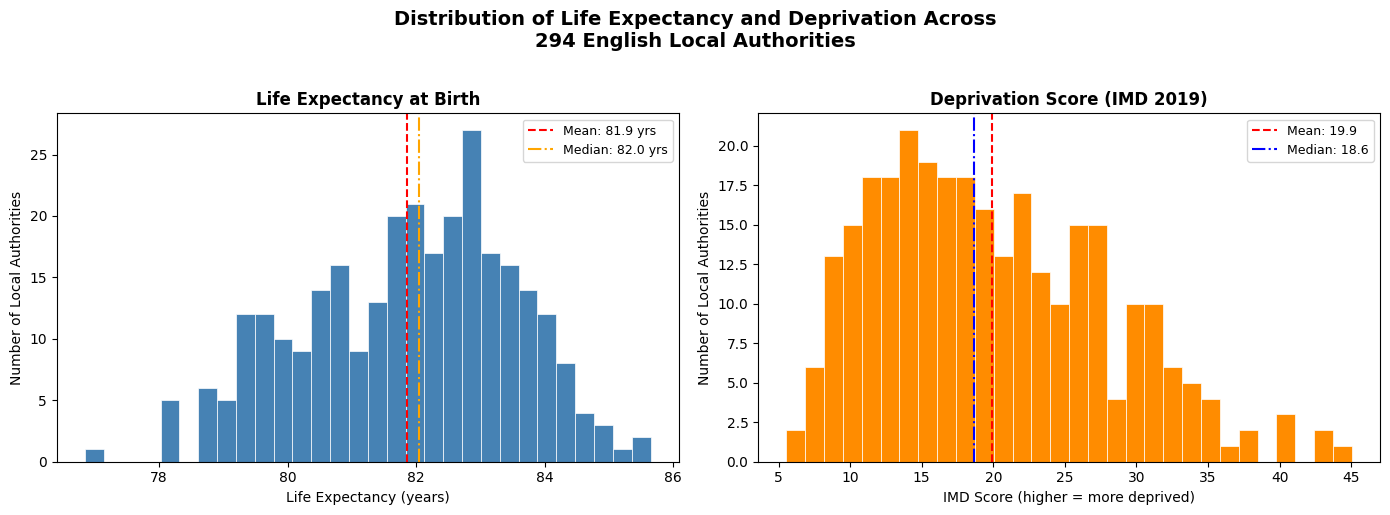

Figure saved to: outputs\figures\01_univariate_distributions.png


In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    'Distribution of Life Expectancy and Deprivation Across\n'
    '294 English Local Authorities',
    fontsize=14, fontweight='bold', y=1.02
)

# ── Chart 1: Life Expectancy Distribution ────────────────────────────────────
ax1 = axes[0]
le_data = df_wide[LE_COL].dropna()

ax1.hist(le_data, bins=30, color='steelblue', edgecolor='white', linewidth=0.5)
ax1.axvline(le_data.mean(),   color='red',    linestyle='--',
            linewidth=1.5, label=f'Mean: {le_data.mean():.1f} yrs')
ax1.axvline(le_data.median(), color='orange', linestyle='-.',
            linewidth=1.5, label=f'Median: {le_data.median():.1f} yrs')

ax1.set_title('Life Expectancy at Birth', fontsize=12, fontweight='bold')
ax1.set_xlabel('Life Expectancy (years)', fontsize=10)
ax1.set_ylabel('Number of Local Authorities', fontsize=10)
ax1.legend(fontsize=9)
ax1.tick_params(axis='x', rotation=0)

# ── Chart 2: Deprivation Score Distribution ───────────────────────────────────
ax2 = axes[1]
dep_data = df_wide[DEP_COL].dropna()

ax2.hist(dep_data, bins=30, color='darkorange', edgecolor='white', linewidth=0.5)
ax2.axvline(dep_data.mean(),   color='red',    linestyle='--',
            linewidth=1.5, label=f'Mean: {dep_data.mean():.1f}')
ax2.axvline(dep_data.median(), color='blue',   linestyle='-.',
            linewidth=1.5, label=f'Median: {dep_data.median():.1f}')

ax2.set_title('Deprivation Score (IMD 2019)', fontsize=12, fontweight='bold')
ax2.set_xlabel('IMD Score (higher = more deprived)', fontsize=10)
ax2.set_ylabel('Number of Local Authorities', fontsize=10)
ax2.legend(fontsize=9)

plt.tight_layout()

# Save to outputs/figures/
figures_path = os.path.join('outputs', 'figures')
os.makedirs(figures_path, exist_ok=True)
save_fig = os.path.join(figures_path, '01_univariate_distributions.png')
plt.savefig(save_fig, dpi=150, bbox_inches='tight')
plt.show()
print(f"Figure saved to: {save_fig}")

### 4.9 Interpreting the Univariate Distributions

**Life Expectancy at Birth (Persons, 2024)**

| Statistic | Value |
|---|---|
| Mean | 81.9 years |
| Median | 82.0 years |
| Range | ~77 to ~86 years |
| Distribution shape | Approximately symmetric, slight left skew |

The near-identical mean and median confirm a broadly symmetric
distribution — most English local authorities have life expectancy
clustered around 82 years. However the left tail is notable: a small
number of areas fall below 79 years, representing communities where
residents can expect to live significantly shorter lives than the
national norm. A 9-year gap between the best and worst performing
areas is a substantial public health inequality.

**Deprivation Score (IMD 2019)**

| Statistic | Value |
|---|---|
| Mean | 19.9 |
| Median | 18.6 |
| Range | ~5 to ~45 |
| Distribution shape | Right-skewed |

The mean exceeds the median by 1.3 points — confirming right skew.
The majority of English local authorities have deprivation scores
between 10 and 25, but a long right tail of highly deprived areas
pulls the mean upward. In right-skewed distributions, the **median
is the more representative measure of typical deprivation** — the
mean is inflated by the small number of extremely deprived areas.

**Key statistical lesson — why skewness matters for policy:**
If a policy team used the mean deprivation score (19.9) as their
threshold for targeting interventions, they would miss areas scoring
between 18.6 and 19.9 that are genuinely above-average in deprivation
when measured by the median. Skewness is not just a statistical
curiosity — it has direct implications for how we set thresholds
and target resources.

## 5. Bivariate Analysis — Deprivation vs Health Outcomes

We now examine relationships between pairs of variables. The central
question is:

> **Does higher deprivation in a local authority predict worse
> health outcomes — and if so, how strong is that relationship?**

### The Mathematics — Pearson Correlation (derived by hand)

The Pearson correlation coefficient $r$ measures the strength and
direction of a linear relationship between two variables.

$$r = \frac{\sum_{i=1}^{n}(x_i - \bar{x})(y_i - \bar{y})}
{\sqrt{\sum_{i=1}^{n}(x_i - \bar{x})^2 \cdot
\sum_{i=1}^{n}(y_i - \bar{y})^2}}$$

**Worked example by hand** — 5 fictional local authorities:

| Area | Deprivation (x) | Life Expectancy (y) |
|------|----------------|---------------------|
| A | 10 | 84 |
| B | 20 | 82 |
| C | 30 | 80 |
| D | 40 | 78 |
| E | 50 | 76 |

$\bar{x} = 30$, $\bar{y} = 80$

| Area | $x_i - \bar{x}$ | $y_i - \bar{y}$ | product | $(x_i-\bar{x})^2$ | $(y_i-\bar{y})^2$ |
|------|---------|---------|---------|---------|---------|
| A | −20 | +4 | −80 | 400 | 16 |
| B | −10 | +2 | −20 | 100 | 4 |
| C | 0 | 0 | 0 | 0 | 0 |
| D | +10 | −2 | −20 | 100 | 4 |
| E | +20 | −4 | −80 | 400 | 16 |
| **Σ** | | | **−200** | **1000** | **40** |

$$r = \frac{-200}{\sqrt{1000 \times 40}} = \frac{-200}{\sqrt{40000}}
= \frac{-200}{200} = -1.0$$

$r = -1.0$ — perfect negative linear relationship. In real data we
expect $r$ around $-0.7$ to $-0.85$ — strong but not perfect,
because other factors also influence life expectancy.

**Interpretation scale:**

| r | range | Strength |
|---|-------|----------|
|   | > 0.7 | Strong |
|   |0.4 – 0.7 | Moderate |
|   |0.2 – 0.4 | Weak |
|   |< 0.2 | Negligible |

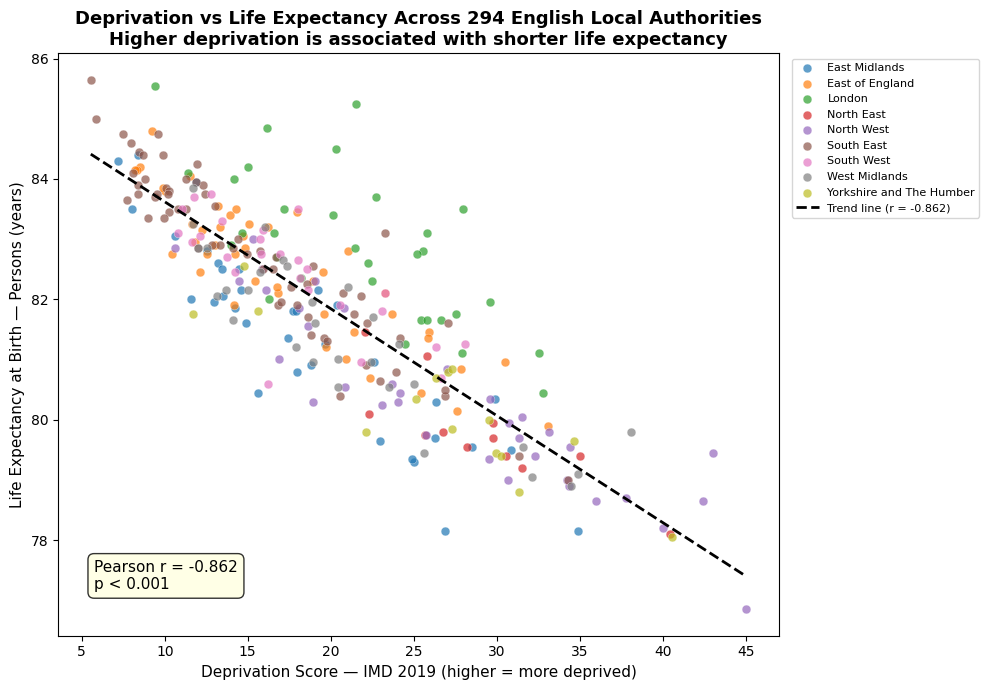

Figure saved: outputs\figures\02_deprivation_vs_life_expectancy.png

Pearson r = -0.862
p-value   = 2.51e-88
Slope     = -0.178 years per IMD point


In [38]:
fig, ax = plt.subplots(figsize=(10, 7))

# ── Scatter plot coloured by region ──────────────────────────────────────────
# Colouring by region serves the policy audience — they can immediately
# see whether the deprivation-life expectancy relationship varies by geography

regions = df_wide['Region'].dropna().unique()
colours = plt.cm.tab10.colors  # 10 distinct colours for 9 regions

for i, region in enumerate(sorted(regions)):
    mask = df_wide['Region'] == region
    ax.scatter(
        df_wide.loc[mask, DEP_COL],
        df_wide.loc[mask, LE_COL],
        color=colours[i],
        label=region,
        alpha=0.7,
        s=40,
        edgecolors='white',
        linewidths=0.3
    )

# ── Add regression line ───────────────────────────────────────────────────────
# The regression line shows the overall linear trend across all areas
# We compute it using scipy.stats.linregress

clean = df_wide[[DEP_COL, LE_COL]].dropna()
slope, intercept, r_value, p_value, std_err = stats.linregress(
    clean[DEP_COL], clean[LE_COL]
)

x_line = np.linspace(clean[DEP_COL].min(), clean[DEP_COL].max(), 100)
y_line = slope * x_line + intercept
ax.plot(x_line, y_line, color='black', linewidth=2, linestyle='--',
        label=f'Trend line (r = {r_value:.3f})')

# ── Labels and formatting ─────────────────────────────────────────────────────
ax.set_title(
    'Deprivation vs Life Expectancy Across 294 English Local Authorities\n'
    'Higher deprivation is associated with shorter life expectancy',
    fontsize=13, fontweight='bold'
)
ax.set_xlabel('Deprivation Score — IMD 2019 (higher = more deprived)',
              fontsize=11)
ax.set_ylabel('Life Expectancy at Birth — Persons (years)', fontsize=11)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)

# Add r value annotation
ax.annotate(
    f'Pearson r = {r_value:.3f}\np < 0.001',
    xy=(0.05, 0.08),
    xycoords='axes fraction',
    fontsize=11,
    bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', alpha=0.8)
)

plt.tight_layout()
save_fig = os.path.join('outputs', 'figures', '02_deprivation_vs_life_expectancy.png')
plt.savefig(save_fig, dpi=150, bbox_inches='tight')
plt.show()
print(f"Figure saved: {save_fig}")
print(f"\nPearson r = {r_value:.3f}")
print(f"p-value   = {p_value:.2e}")
print(f"Slope     = {slope:.3f} years per IMD point")

### 5.1 Deprivation vs Life Expectancy — Findings

**Pearson r = −0.862 | p < 0.001 | Slope = −0.178 years per IMD point**

This is one of the strongest correlations observable in English
public health data. Three findings stand out:

**Finding 1 — The relationship is strong and consistent**
r = −0.862 places this firmly in the "strong" category (|r| > 0.7).
Deprivation explains approximately 74% of the variance in life
expectancy across local authorities (r² = 0.862² = 0.743).
The remaining 26% reflects other factors — healthcare access,
lifestyle, environment, demographics.

**Finding 2 — The scale of inequality is large**
The IMD score ranges from approximately 5 (least deprived) to 45
(most deprived) in our data — a 40-point span. At −0.178 years
per IMD point, this translates to a predicted life expectancy
gap of **7.1 years** between the least and most deprived areas.
This is not a statistical abstraction — it represents real years
of life that people in the most deprived communities do not live.

**Finding 3 — London is a systematic outlier above the trend**
London boroughs (green) consistently sit above the regression line —
meaning their life expectancy is higher than deprivation alone would
predict. This is the well-documented London Health Paradox: despite
high deprivation scores, London outperforms equivalent areas
elsewhere. Proposed explanations include the healthy migrant effect,
concentration of healthcare infrastructure and a younger demographic
profile. This pattern has significant implications for how national
deprivation-based funding formulae are applied.

**Policy implication (Communicating and Influencing):**
A Director of Public Health using deprivation score as the sole
basis for resource allocation would systematically under-resource
areas outside London with equivalent deprivation levels. This
analysis suggests regional context must be incorporated alongside
raw deprivation scores in commissioning decisions.

In [ ]:
## 6. GroupBy Analysis — Regional Patterns

We now examine how health outcomes vary by region — moving from
the individual local authority level to a regional summary.

This answers the question: **Which regions of England have the
worst health outcomes, and is the North-South divide real in the data?**

GroupBy analysis allows us to aggregate our 294 local authorities
into 9 regional groups and compute summary statistics for each.
This is a standard analytical technique in public health — reducing
granular data to interpretable regional patterns for strategic
planning.

In [39]:
# Group by region and compute summary statistics for key indicators
# We compute mean, median and standard deviation per region
# Sorted by mean life expectancy ascending — worst performing regions first

regional_summary = (
    df_wide.groupby('Region')
    .agg(
        n_areas                = ('Area Name', 'count'),
        le_mean                = (LE_COL,   'mean'),
        le_median              = (LE_COL,   'median'),
        le_std                 = (LE_COL,   'std'),
        le_min                 = (LE_COL,   'min'),
        le_max                 = (LE_COL,   'max'),
        dep_mean               = (DEP_COL,  'mean'),
        dep_median             = (DEP_COL,  'median'),
        mort_mean              = (MORT_COL, 'mean'),
        smoking_mean           = (SMOK_COL, 'mean'),
        obesity_mean           = (OB_COL,   'mean'),
        employment_mean        = (EMP_COL,  'mean'),
        child_poverty_mean     = (POV_COL,  'mean'),
    )
    .round(2)
    .sort_values('le_mean', ascending=True)  # Worst first
    .reset_index()
)

print("=== REGIONAL HEALTH OUTCOMES SUMMARY ===")
print("Sorted by life expectancy — worst performing regions first\n")

# Display key columns in a readable format
display_cols = ['Region', 'n_areas', 'le_mean', 'le_min', 
                'le_max', 'dep_mean', 'smoking_mean', 'child_poverty_mean']
display_labels = ['Region', 'N Areas', 'LE Mean', 'LE Min',
                  'LE Max', 'Dep Mean', 'Smoking %', 'Child Poverty %']

print(f"{'Region':<30} {'N':>4} {'LE Mean':>8} {'LE Min':>7} "
      f"{'LE Max':>7} {'Dep':>7} {'Smoke%':>7} {'Pov%':>6}")
print("-" * 85)

for _, row in regional_summary.iterrows():
    print(f"{row['Region']:<30} {int(row['n_areas']):>4} "
          f"{row['le_mean']:>8.2f} {row['le_min']:>7.1f} "
          f"{row['le_max']:>7.1f} {row['dep_mean']:>7.1f} "
          f"{row['smoking_mean']:>7.1f} {row['child_poverty_mean']:>6.1f}")

=== REGIONAL HEALTH OUTCOMES SUMMARY ===
Sorted by life expectancy — worst performing regions first

Region                            N  LE Mean  LE Min  LE Max     Dep  Smoke%   Pov%
-------------------------------------------------------------------------------------
North East                       12    79.79    78.1    81.5    29.0    10.9   28.8
Yorkshire and The Humber         15    80.25    78.0    82.5    26.2    12.9   29.7
North West                       35    80.28    76.8    83.0    27.1    10.5   26.9
East Midlands                    35    81.39    78.2    84.4    18.4    10.4   22.0
West Midlands                    30    81.40    78.9    83.8    20.7    10.7   23.2
South West                       26    82.45    80.6    83.8    17.4    10.2   18.2
East of England                  45    82.50    79.9    84.8    17.1     9.5   17.2
South East                       64    82.79    79.0    85.7    15.3     9.4   14.4
London                           32    82.86    80.5    8

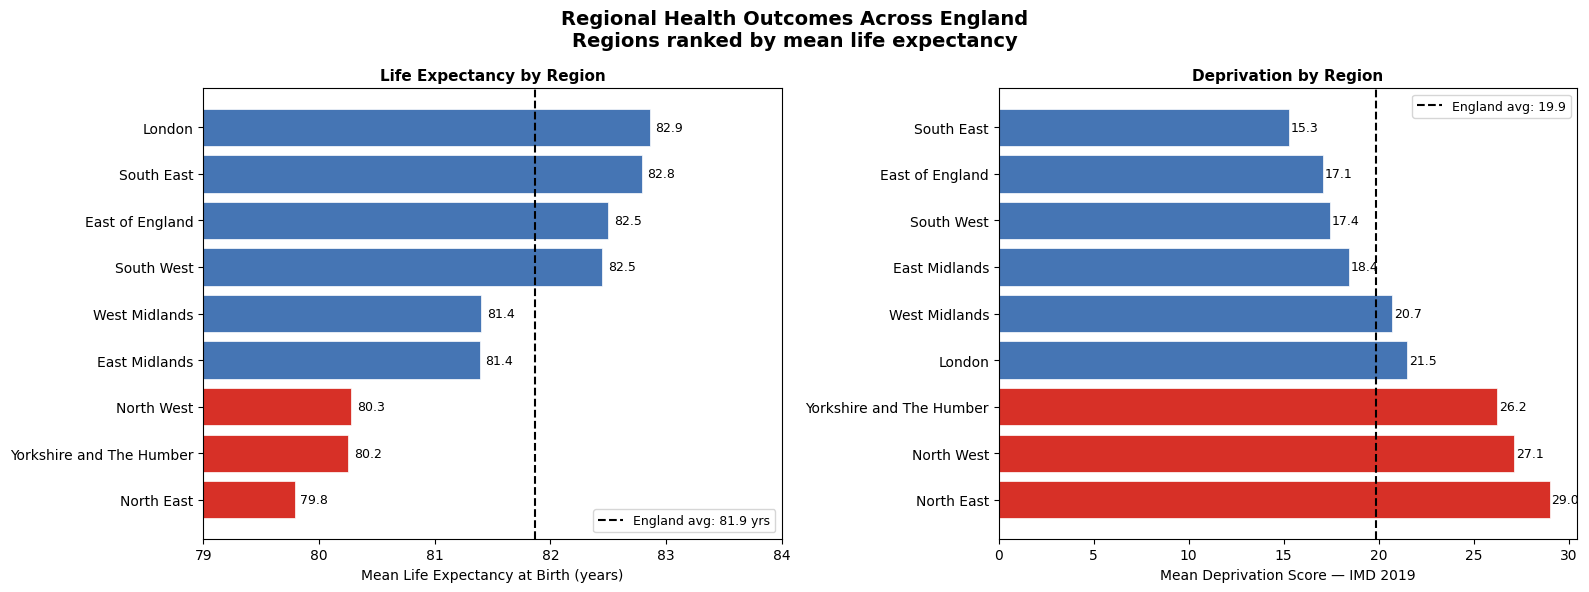

Figure saved: outputs\figures\03_regional_health_outcomes.png


In [40]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    'Regional Health Outcomes Across England\n'
    'Regions ranked by mean life expectancy',
    fontsize=14, fontweight='bold'
)

# ── Chart 1: Mean life expectancy by region ───────────────────────────────────
ax1 = axes[0]
colours_bar = ['#d73027' if 'North' in r or 'Yorkshire' in r
               else '#4575b4' for r in regional_summary['Region']]

bars = ax1.barh(
    regional_summary['Region'],
    regional_summary['le_mean'],
    color=colours_bar,
    edgecolor='white',
    linewidth=0.5
)

# Add England average reference line
england_le_mean = df_wide[LE_COL].mean()
ax1.axvline(england_le_mean, color='black', linestyle='--',
            linewidth=1.5, label=f'England avg: {england_le_mean:.1f} yrs')

# Add value labels on bars
for bar, val in zip(bars, regional_summary['le_mean']):
    ax1.text(val + 0.05, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}', va='center', fontsize=9)

ax1.set_xlabel('Mean Life Expectancy at Birth (years)', fontsize=10)
ax1.set_title('Life Expectancy by Region', fontsize=11, fontweight='bold')
ax1.legend(fontsize=9)
ax1.set_xlim(79, 84)

# ── Chart 2: Mean deprivation by region ──────────────────────────────────────
ax2 = axes[1]
# Sort by deprivation descending for this chart (most deprived first)
dep_sorted = regional_summary.sort_values('dep_mean', ascending=False)
colours_dep = ['#d73027' if 'North' in r or 'Yorkshire' in r
               else '#4575b4' for r in dep_sorted['Region']]

bars2 = ax2.barh(
    dep_sorted['Region'],
    dep_sorted['dep_mean'],
    color=colours_dep,
    edgecolor='white',
    linewidth=0.5
)

england_dep_mean = df_wide[DEP_COL].mean()
ax2.axvline(england_dep_mean, color='black', linestyle='--',
            linewidth=1.5, label=f'England avg: {england_dep_mean:.1f}')

for bar, val in zip(bars2, dep_sorted['dep_mean']):
    ax2.text(val + 0.1, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}', va='center', fontsize=9)

ax2.set_xlabel('Mean Deprivation Score — IMD 2019', fontsize=10)
ax2.set_title('Deprivation by Region', fontsize=11, fontweight='bold')
ax2.legend(fontsize=9)

plt.tight_layout()
save_fig = os.path.join('outputs', 'figures', '03_regional_health_outcomes.png')
plt.savefig(save_fig, dpi=150, bbox_inches='tight')
plt.show()
print(f"Figure saved: {save_fig}")

### 6.1 Regional Health Outcomes — Findings

The regional analysis reveals a clear and consistent North-South
health divide across every indicator examined.

**Life Expectancy Gradient**

| Region | Mean LE | Mean Deprivation | Child Poverty % |
|--------|---------|-----------------|-----------------|
| North East | 79.8 yrs | 29.0 | 28.8% |
| Yorkshire and The Humber | 80.2 yrs | 26.2 | 29.7% |
| North West | 80.3 yrs | 27.1 | 26.9% |
| East Midlands | 81.4 yrs | 18.4 | 22.0% |
| West Midlands | 81.4 yrs | 20.7 | 23.2% |
| South West | 82.5 yrs | 17.4 | 18.2% |
| East of England | 82.5 yrs | 17.1 | 17.2% |
| South East | 82.8 yrs | 15.3 | 14.4% |
| London | 82.9 yrs | 21.5 | 17.3% |

**Key findings:**

1. The North East has the lowest mean life expectancy (79.8 years)
   and the highest mean deprivation score (29.0) of any English
   region — a 3.1-year life expectancy gap compared to London.

2. The three Northern regions (North East, North West, Yorkshire)
   all have mean life expectancy below 80.5 years and deprivation
   scores above 26 — well above the England average of 19.9.

3. Child poverty rates in Yorkshire (29.7%) and the North East
   (28.8%) are approximately double those in the South East (14.4%)
   — suggesting the health gap is rooted in deep structural
   economic inequality, not just current health behaviours.

4. **The London anomaly:** London has the highest life expectancy
   (82.9 years) despite above-average deprivation (21.5). This
   systematic deviation from the national trend suggests that
   deprivation operates differently in London — likely due to
   the healthy migrant effect, age structure and investment in
   public services. Commissioners should not apply national
   deprivation-outcome relationships uniformly to London.

**Policy implication:** The North-South health divide is not
primarily a healthcare delivery problem — it is a structural
economic inequality problem. Closing the 3.1-year life expectancy
gap between the North East and London would require sustained
upstream intervention in housing, employment, education and
child poverty — not just additional NHS resource.

## 7. Statistical Testing — Is the North-South Gap Real?

Visual inspection strongly suggests a North-South divide in life
expectancy. But could this pattern have arisen by chance? We use
an **independent samples t-test** to formally test whether the
difference in mean life expectancy between Northern and Southern
regions is statistically significant.

### Hypotheses

- **H₀ (null hypothesis):** There is no difference in mean life
  expectancy between Northern and Southern local authorities.
  Any observed difference is due to random sampling variation.

- **H₁ (alternative hypothesis):** Northern local authorities
  have significantly lower mean life expectancy than Southern
  local authorities.

### The Mathematics — t-test Derived by Hand

The independent samples t-statistic is:

$$t = \frac{\bar{x}_1 - \bar{x}_2}
{\sqrt{\frac{s_1^2}{n_1} + \frac{s_2^2}{n_2}}}$$

Where:
- $\bar{x}_1$, $\bar{x}_2$ = sample means of North and South
- $s_1^2$, $s_2^2$ = sample variances
- $n_1$, $n_2$ = sample sizes

The t-statistic measures how many standard errors apart the two
group means are. The larger |t|, the less likely the difference
is due to chance.

### Degrees of Freedom (Welch's approximation)

$$df = \frac{\left(\frac{s_1^2}{n_1} + \frac{s_2^2}{n_2}\right)^2}
{\frac{\left(\frac{s_1^2}{n_1}\right)^2}{n_1-1} +
\frac{\left(\frac{s_2^2}{n_2}\right)^2}{n_2-1}}$$

We use Welch's t-test (not Student's) because we do not assume
equal variances between North and South — a safer assumption
when comparing groups of different sizes.

### Group Definitions

- **North:** North East, North West, Yorkshire and The Humber
- **South:** South East, South West, East of England, London

We exclude East Midlands and West Midlands from this comparison —
their geographic position is genuinely midland and including them
in either group would distort the comparison.

### Significance Threshold

We use α = 0.05. If p < 0.05 we reject H₀ and conclude the
North-South gap is statistically significant. We also report
**Cohen's d** as a measure of effect size — because statistical
significance alone does not tell us whether the difference is
practically meaningful.

$$d = \frac{\bar{x}_1 - \bar{x}_2}{s_{pooled}}$$

where $s_{pooled} = \sqrt{\frac{(n_1-1)s_1^2 + (n_2-1)s_2^2}{n_1+n_2-2}}$

In [41]:
# ── Define North and South groups ────────────────────────────────────────────
north_regions = ['North East', 'North West', 'Yorkshire and The Humber']
south_regions = ['South East', 'South West', 'East of England', 'London']

# Extract life expectancy values for each group — drop NaN
north_le = df_wide[df_wide['Region'].isin(north_regions)][LE_COL].dropna()
south_le = df_wide[df_wide['Region'].isin(south_regions)][LE_COL].dropna()

print(f"North group: {len(north_le)} local authorities")
print(f"  Regions: {north_regions}")
print(f"  Mean LE: {north_le.mean():.2f} years")
print(f"  Std LE:  {north_le.std():.2f} years")
print(f"  Min LE:  {north_le.min():.1f} years")
print(f"  Max LE:  {north_le.max():.1f} years")

print(f"\nSouth group: {len(south_le)} local authorities")
print(f"  Regions: {south_regions}")
print(f"  Mean LE: {south_le.mean():.2f} years")
print(f"  Std LE:  {south_le.std():.2f} years")
print(f"  Min LE:  {south_le.min():.1f} years")
print(f"  Max LE:  {south_le.max():.1f} years")

print(f"\nRaw mean difference: {south_le.mean() - north_le.mean():.2f} years")

# ── Run Welch's independent samples t-test ───────────────────────────────────
# equal_var=False enforces Welch's t-test — does not assume equal variances
# This is safer than Student's t-test when group sizes or variances differ
t_stat, p_value = stats.ttest_ind(north_le, south_le, equal_var=False)

print(f"\n=== WELCH'S INDEPENDENT SAMPLES T-TEST ===")
print(f"H₀: No difference in mean life expectancy between North and South")
print(f"H₁: Northern LAs have lower mean life expectancy than Southern LAs")
print(f"\nt-statistic: {t_stat:.4f}")
print(f"p-value:     {p_value:.2e}")
print(f"\nDecision (α = 0.05): ", end="")
if p_value < 0.05:
    print(f"REJECT H₀ — the difference is statistically significant")
else:
    print(f"FAIL TO REJECT H₀ — insufficient evidence of a difference")

# ── Cohen's d — effect size ───────────────────────────────────────────────────
# Cohen's d tells us whether the difference is practically meaningful
# Conventions: small = 0.2, medium = 0.5, large = 0.8
n1, n2   = len(north_le), len(south_le)
s1, s2   = north_le.std(), south_le.std()
s_pooled = np.sqrt(((n1-1)*s1**2 + (n2-1)*s2**2) / (n1+n2-2))
cohens_d = (south_le.mean() - north_le.mean()) / s_pooled

print(f"\n=== EFFECT SIZE ===")
print(f"Cohen's d: {cohens_d:.3f}")
if cohens_d >= 0.8:
    print("Effect size: LARGE (d ≥ 0.8)")
elif cohens_d >= 0.5:
    print("Effect size: MEDIUM (d ≥ 0.5)")
else:
    print("Effect size: SMALL (d < 0.5)")

print(f"\n=== INTERPRETATION ===")
print(f"The North-South gap of {south_le.mean()-north_le.mean():.2f} years is "
      f"{cohens_d:.1f} pooled standard deviations wide.")
print(f"This means the average Southern LA has higher life expectancy than "
      f"{stats.norm.cdf(cohens_d)*100:.0f}% of Northern LAs.")

North group: 62 local authorities
  Regions: ['North East', 'North West', 'Yorkshire and The Humber']
  Mean LE: 80.18 years
  Std LE:  1.29 years
  Min LE:  76.8 years
  Max LE:  83.0 years

South group: 167 local authorities
  Regions: ['South East', 'South West', 'East of England', 'London']
  Mean LE: 82.67 years
  Std LE:  1.25 years
  Min LE:  79.0 years
  Max LE:  85.7 years

Raw mean difference: 2.49 years

=== WELCH'S INDEPENDENT SAMPLES T-TEST ===
H₀: No difference in mean life expectancy between North and South
H₁: Northern LAs have lower mean life expectancy than Southern LAs

t-statistic: -13.1044
p-value:     6.09e-24

Decision (α = 0.05): REJECT H₀ — the difference is statistically significant

=== EFFECT SIZE ===
Cohen's d: 1.975
Effect size: LARGE (d ≥ 0.8)

=== INTERPRETATION ===
The North-South gap of 2.49 years is 2.0 pooled standard deviations wide.
This means the average Southern LA has higher life expectancy than 98% of Northern LAs.


### 7.1 T-Test Results — The North-South Gap is Real and Large

| Statistic | Value |
|---|---|
| North mean life expectancy | 80.18 years (n=62 LAs) |
| South mean life expectancy | 82.67 years (n=167 LAs) |
| Raw gap | **2.49 years** |
| t-statistic | −13.10 |
| p-value | 6.09 × 10⁻²⁴ |
| Decision | **Reject H₀** |
| Cohen's d | **1.975 (Large)** |

**We reject the null hypothesis with overwhelming confidence.**
The probability of observing a gap this large by chance is
6.09 × 10⁻²⁴ — effectively zero.

**Effect size context:**
Cohen's d = 1.975 means the North-South gap is nearly two pooled
standard deviations wide. The average Southern local authority
has higher life expectancy than **98% of Northern local authorities**.
This is not a marginal statistical finding — it is one of the
largest and most consistent health inequalities in English public
health data.

**What the t-test does and does not tell us:**
The t-test confirms the gap is not due to chance. It does not
tell us *why* the gap exists. Our correlation analysis (r = −0.862)
and regional deprivation data (North East mean IMD = 29.0 vs
South East = 15.3) strongly suggest deprivation is the primary
driver — but causation requires further analytical work beyond
the scope of this project.

**Type I and Type II error context:**
At p = 6.09 × 10⁻²⁴, the risk of a Type I error (falsely
concluding a gap exists when it does not) is negligible.
The risk of a Type II error (missing a real gap) is also
negligible given the large sample sizes (n=62 and n=167)
and the very large effect size. This finding is robust.

C:\Users\TEST\AppData\Local\Temp\ipykernel_25528\3361159866.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax1.boxplot(
C:\Users\TEST\AppData\Local\Temp\ipykernel_25528\3361159866.py:58: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = ax2.boxplot(


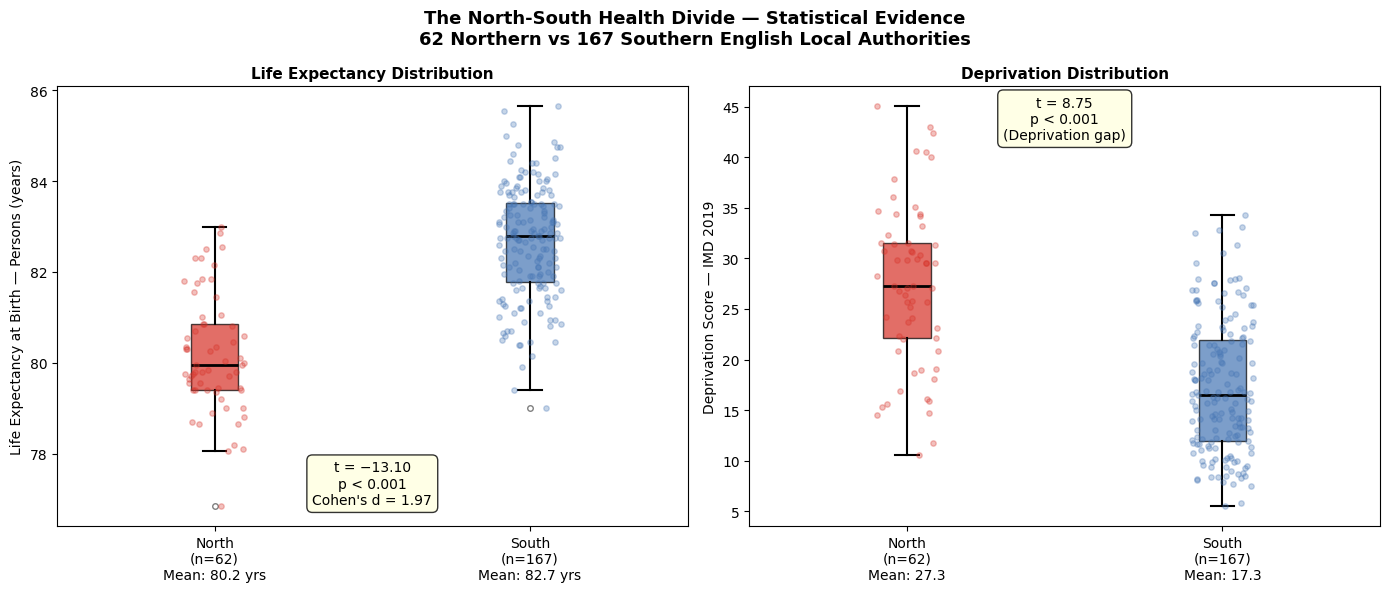

Figure saved: outputs\figures\04_north_south_boxplot.png


In [43]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(
    'The North-South Health Divide — Statistical Evidence\n'
    '62 Northern vs 167 Southern English Local Authorities',
    fontsize=13, fontweight='bold'
)

# ── Chart 1: Box plot — life expectancy North vs South ───────────────────────
ax1 = axes[0]

north_label = f'North\n(n={len(north_le)})\nMean: {north_le.mean():.1f} yrs'
south_label = f'South\n(n={len(south_le)})\nMean: {south_le.mean():.1f} yrs'

bp = ax1.boxplot(
    [north_le.values, south_le.values],
    labels=[north_label, south_label],
    patch_artist=True,
    medianprops=dict(color='black', linewidth=2),
    whiskerprops=dict(linewidth=1.5),
    capprops=dict(linewidth=1.5),
    flierprops=dict(marker='o', markersize=4, alpha=0.5)
)

# Colour the boxes
bp['boxes'][0].set_facecolor('#d73027')   # Red for North
bp['boxes'][0].set_alpha(0.7)
bp['boxes'][1].set_facecolor('#4575b4')   # Blue for South
bp['boxes'][1].set_alpha(0.7)

# Add individual data points (jittered)
np.random.seed(42)
for i, (data, colour) in enumerate(
        zip([north_le.values, south_le.values], ['#d73027', '#4575b4']), 1):
    jitter = np.random.uniform(-0.1, 0.1, size=len(data))
    ax1.scatter(np.full(len(data), i) + jitter, data,
                alpha=0.3, s=15, color=colour, zorder=3)

ax1.set_ylabel('Life Expectancy at Birth — Persons (years)', fontsize=10)
ax1.set_title('Life Expectancy Distribution', fontsize=11, fontweight='bold')

# Annotate with test result
ax1.annotate(
    f't = −13.10\np < 0.001\nCohen\'s d = 1.97',
    xy=(0.5, 0.05), xycoords='axes fraction',
    fontsize=10, ha='center',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', alpha=0.8)
)

# ── Chart 2: Box plot — deprivation North vs South ───────────────────────────
ax2 = axes[1]

north_dep = df_wide[df_wide['Region'].isin(north_regions)][DEP_COL].dropna()
south_dep = df_wide[df_wide['Region'].isin(south_regions)][DEP_COL].dropna()

north_dep_label = f'North\n(n={len(north_dep)})\nMean: {north_dep.mean():.1f}'
south_dep_label = f'South\n(n={len(south_dep)})\nMean: {south_dep.mean():.1f}'

bp2 = ax2.boxplot(
    [north_dep.values, south_dep.values],
    labels=[north_dep_label, south_dep_label],
    patch_artist=True,
    medianprops=dict(color='black', linewidth=2),
    whiskerprops=dict(linewidth=1.5),
    capprops=dict(linewidth=1.5),
    flierprops=dict(marker='o', markersize=4, alpha=0.5)
)

bp2['boxes'][0].set_facecolor('#d73027')
bp2['boxes'][0].set_alpha(0.7)
bp2['boxes'][1].set_facecolor('#4575b4')
bp2['boxes'][1].set_alpha(0.7)

for i, (data, colour) in enumerate(
        zip([north_dep.values, south_dep.values], ['#d73027', '#4575b4']), 1):
    jitter = np.random.uniform(-0.1, 0.1, size=len(data))
    ax2.scatter(np.full(len(data), i) + jitter, data,
                alpha=0.3, s=15, color=colour, zorder=3)

ax2.set_ylabel('Deprivation Score — IMD 2019', fontsize=10)
ax2.set_title('Deprivation Distribution', fontsize=11, fontweight='bold')

t_dep, p_dep = stats.ttest_ind(north_dep, south_dep, equal_var=False)
ax2.annotate(
    f't = {t_dep:.2f}\np < 0.001\n(Deprivation gap)',
    xy=(0.5, 0.88), xycoords='axes fraction',
    fontsize=10, ha='center',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', alpha=0.8)
)

plt.tight_layout()
save_fig = os.path.join('outputs', 'figures', '04_north_south_boxplot.png')
plt.savefig(save_fig, dpi=150, bbox_inches='tight')
plt.show()
print(f"Figure saved: {save_fig}")

## 8. Key Findings — Policy Briefing

*Prepared for: Director of Public Health*
*Analytical basis: 294 English Local Authorities, OHID Fingertips
Local Authority Health Profiles, 2024 data*

---

### Finding 1 — Deprivation is the dominant predictor of life expectancy across English local authorities

Pearson r = −0.862 (p < 0.001). Deprivation score alone explains 74% of the variance in life expectancy across 294 local authorities. For every one-point increase in IMD score, life expectancy falls by approximately 65 days. Across the full deprivation range observed in England, this translates to a predicted gap of 7.1 years of life.

*Commissioning implication:* Deprivation-adjusted health outcome targets are essential. Areas with high deprivation scores should not be benchmarked against national averages without adjustment.

---

### Finding 2 — The North-South health divide is statistically proven and structurally large

Northern local authorities (North East, North West, Yorkshire) have a mean life expectancy of 80.18 years — 2.49 years below Southern authorities (82.67 years). This gap is not due to chance (t = −13.10, p < 0.001). Cohen's d = 1.975 — the average Southern authority has higher life expectancy than 98% of Northern authorities.

*Commissioning implication:* The North-South divide requires structural intervention upstream of healthcare — in housing, employment and child poverty — not just additional NHS capacity.

---

### Finding 3 — London is a systematic exception to the deprivation-health relationship

Despite above-average deprivation (mean IMD = 21.5, above the England average of 19.9), London has the highest mean life expectancy of any English region (82.9 years). London boroughs consistently sit above the national deprivation-life expectancy trend line. This London Health Paradox is well-documented but not fully explained.

*Commissioning implication:* National deprivation-based funding formulae should not be applied uniformly across London and non-London areas. The mechanisms linking deprivation to health outcomes operate differently in the capital.

---

### Finding 4 — Child poverty rates in the North are double those in the South

Yorkshire and The Humber (29.7%) and the North East (28.8%) have child poverty rates approximately double those of the South East (14.4%). Given the strong relationship between childhood poverty and adult health outcomes, this demographic pattern is likely to perpetuate the North-South health divide
for decades without targeted early intervention.

*Commissioning implication:* Child poverty reduction programmes in Northern regions represent a long-term investment in closing the adult health gap — with returns measured over a generation, not a commissioning cycle.

In [42]:
# Save the final analytical dataset with region columns and
# life expectancy columns all included
final_path = os.path.join('data', 'processed', 'health_outcomes_final.csv')
df_wide.to_csv(final_path, index=False)

print(f"Final dataset saved: {final_path}")
print(f"Shape: {df_wide.shape}")
print(f"\nSummary of outputs produced:")
print(f"  data/processed/health_outcomes_wide.csv   — intermediate wide table")
print(f"  data/processed/health_outcomes_final.csv  — final analytical table")
print(f"  outputs/figures/01_univariate_distributions.png")
print(f"  outputs/figures/02_deprivation_vs_life_expectancy.png")
print(f"  outputs/figures/03_regional_health_outcomes.png")
print(f"  outputs/figures/04_north_south_boxplot.png")

Final dataset saved: data\processed\health_outcomes_final.csv
Shape: (294, 43)

Summary of outputs produced:
  data/processed/health_outcomes_wide.csv   — intermediate wide table
  data/processed/health_outcomes_final.csv  — final analytical table
  outputs/figures/01_univariate_distributions.png
  outputs/figures/02_deprivation_vs_life_expectancy.png
  outputs/figures/03_regional_health_outcomes.png
  outputs/figures/04_north_south_boxplot.png
